# Water Potability Analysis – Group Report

This notebook contains four main sections addressing different analytical questions on the water potability dataset.

### Import Libraries

In [4]:
# Import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

### Load Dataset

In [6]:
# Load the dataset
df = pd.read_csv('water_potability.csv')

# Make a working copy for analysis
df_copy = df.copy()

# Display the first few rows
df_copy.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Handling Missing Values 
Rows with missing values were removed to ensure descriptive statistics reflect true recorded data without imputed values.

In [8]:
# Remove rows with missing values; ensures all columns, including 'ph', are complete
df_cleaned = df_copy.dropna()

# Check how many rows and columns are left
print(df_cleaned.shape)

(2011, 10)


## Question 1: Exploratory Analysis by Khivanraj

# Exploratory Analysis of Water Potability

**Question:** What relationships exist among water quality indicators, and how can clustering reveal patterns linked to potability?

**Objective:** Explore relationships among water quality features using correlation analysis and clustering to identify patterns associated with potable and non-potable samples.

### Correlation Heatmap of Physicochemical Water Quality Parameters and Potability
High correlations (close to +1 or -1) indicate strong relationships between water quality indicators and/or potability. 

Near-zero values indicate weak or no linear relationship. 

This heatmap helps identify key feature relationships for further exploration.

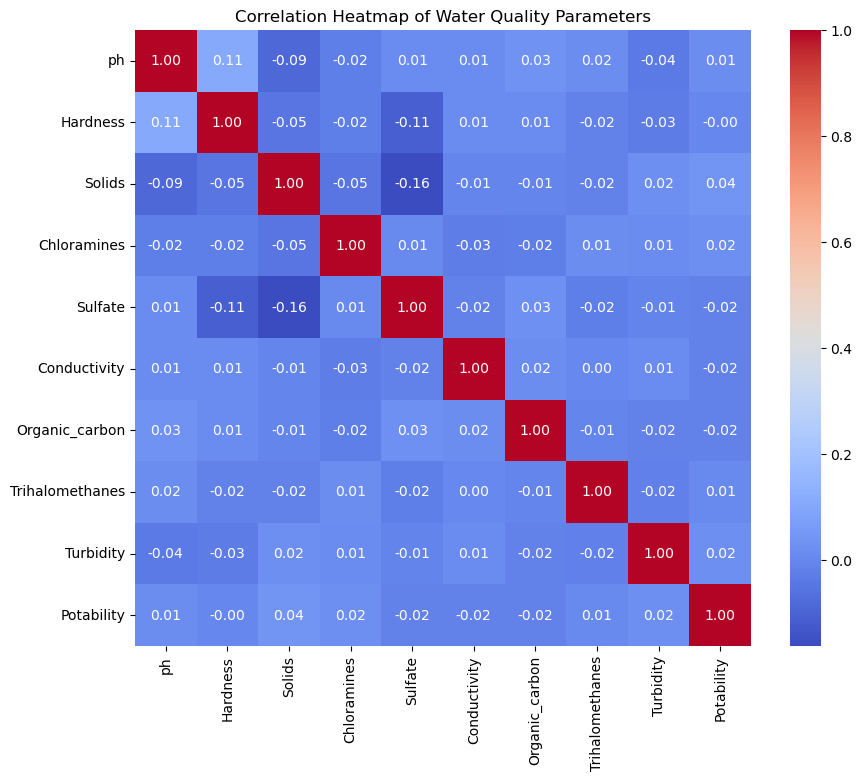

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap of Water Quality Parameters")
plt.show()

### Unsupervised Clustering of Water Samples Based on Physicochemical Features (PCA Projection)
KMeans clustering, combined with PCA projection, was applied to group water samples based on their physicochemical properties. This helps reveal natural groupings that may be linked to potability.

The number of clusters (k=2) was chosen based on the elbow method demonstrated in our lab exercise, ensuring a good balance between cluster compactness and separation.

In [13]:
# Step 1: Prepare features for clustering (drop the target label)
features = df_cleaned.drop("Potability", axis=1)

# Step 2: Standardize the feature values for PCA and KMeans
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 3: Apply KMeans clustering to group the water samples into 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Make an explicit copy to avoid SettingWithCopyWarning
df_cleaned = df_cleaned.copy()

# Assign the cluster labels safely
df_cleaned["Cluster"] = kmeans.fit_predict(scaled_features)

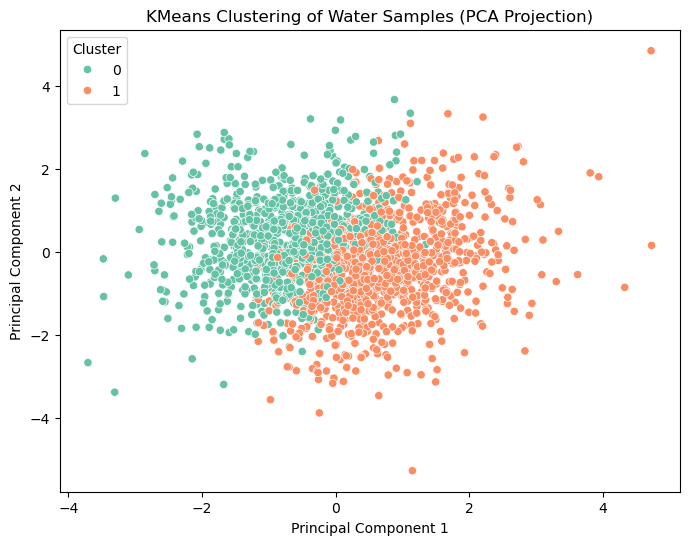

In [14]:
# Step 4: Apply PCA to reduce dimensionality for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

# Store the first two principal components in the dataframe
df_cleaned["PCA1"] = pca_result[:, 0]
df_cleaned["PCA2"] = pca_result[:, 1]

# Step 5: Visualize the clusters using a PCA projection
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df_cleaned, palette="Set2")
plt.title("KMeans Clustering of Water Samples (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

### KMeans Clustering of Water Samples (PCA Projection)

The scatter plot above shows the result of KMeans clustering applied to the water quality dataset, visualized using the first two principal components derived from PCA. Each point represents a water sample, and its color indicates its assigned cluster (Cluster 0 or Cluster 1).

The PCA projection reveals two well-separated clusters along the first principal component, indicating that the KMeans algorithm has successfully identified distinct groupings within the data. This clear separation suggests strong underlying patterns in the physicochemical properties of the water samples that may relate to potability or other quality characteristics.

In [16]:
# Data preprocessing, PCA, clustering, and setup for classification

# Step 1: Scale features
features = df_cleaned.drop("Potability", axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Make a copy to safely add new columns without warnings
df_cleaned = df_cleaned.copy()

# Step 2: PCA for visualization
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(scaled_features)
df_cleaned["PCA1"] = pca_result[:, 0]
df_cleaned["PCA2"] = pca_result[:, 1]

# Step 3: KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_cleaned["Cluster"] = kmeans.fit_predict(scaled_features)

# Step 4: Prepare data for classification (exclude PCA + Cluster columns)
X = df_cleaned.drop(["Potability", "Cluster", "PCA1", "PCA2"], axis=1)
y = df_cleaned["Potability"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [17]:
# Preview PCA results
df_cleaned[["PCA1", "PCA2"]].head()

,PCA1,PCA2
3,-0.317997,-0.353802
4,-1.098343,0.234810
5,1.712809,-0.086235
6,-2.936618,0.404744
7,-1.562092,1.134595


In [18]:
# Preview Cluster results
df_cleaned["Cluster"].value_counts()

Cluster
1    1050
0     961
Name: count, dtype: int64

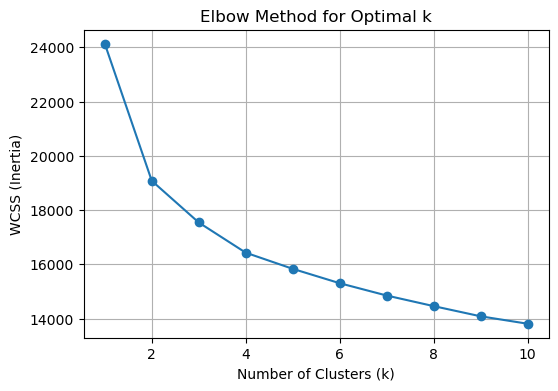

In [19]:
# Prepare features and scale them
features = df_cleaned.drop("Potability", axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Elbow Method to determine optimal k
wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(6, 4))
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()


### Comparison heatmap

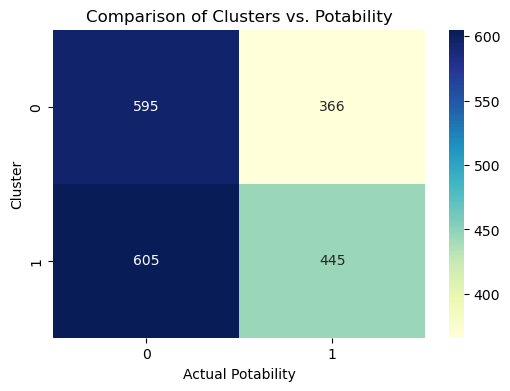

In [21]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    pd.crosstab(df_cleaned["Cluster"], df_cleaned["Potability"]),
    annot=True, cmap="YlGnBu", fmt="d"
)
plt.title("Comparison of Clusters vs. Potability")
plt.xlabel("Actual Potability")
plt.ylabel("Cluster")
plt.show()

plt.show()

### Heatmap: Comparison of KMeans Clusters vs. Actual Potability

The heatmap above visualizes the relationship between the clusters generated by the unsupervised KMeans algorithm and the actual potability labels. Each cell represents the number of water samples falling into a specific combination of cluster and potability class.

Although the clustering was performed without access to the `Potability` labels, we can observe some alignment between the clusters and the true labels. However, there is also significant overlap, indicating that the clustering does not perfectly distinguish between potable and non-potable water. This comparison helps evaluate how much natural structure exists in the data and to what extent it corresponds to real-world classifications.

### Exploratory Insights Summary

This section explored relationships between water quality indicators and potability. Correlation analysis highlighted feature relationships, while KMeans clustering revealed groupings that partly align with potability labels. These insights help identify which indicators contribute to patterns in potable and non-potable water.

## Question 2: Descriptive Analysis by Yubbhashana

# Descriptive Analysis of Water Potability

**Question:** What is the overall distribution of the top 5 key water quality indicators which strongly influence potability, and how do these indicators differ between potable and non-potable samples?

**Objective:** Summarize key statistics (mean, median, standard deviation, range) of water quality features using basic descriptive analysis and visual comparison.

### Step 1: Selection of Key Water Quality Indicators

The **top 5 indicators (pH, Sulfate, Solids, Turbidity, Chloramines)** were selected based on domain knowledge and their importance in water quality assessments, as highlighted by **WHO (2017)** guidelines, rather than on statistical correlation.

### Step 2: Summary Statistics of Key Water Quality Indicators

**The table below shows mean, median, standard deviation, minimum, and maximum for key features, grouped by Potability.**

In [28]:
# Compute grouped descriptive statistics
grouped_stats = df_cleaned.groupby("Potability")[["ph", "Sulfate", "Solids", "Turbidity", "Chloramines"]].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

# Adjust display settings so full table shows
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Display the table
grouped_stats

ph                                              Sulfate  \
                mean    median       std       min        max        mean   
Potability                                                                  
0           7.067201  6.992004  1.659106  1.431782  14.000000  333.742928   
1           7.113791  7.046549  1.437623  0.227499  11.898078  332.457832   

                                                                 Solids  \
                median        std         min         max          mean   
Potability                                                                
0           332.615625  36.398403  203.444521  460.107069  21628.535122   
1           331.087177  47.446190  129.000000  481.030642  22344.922883   

                                                                 Turbidity  \
                  median          std          min           max      mean   
Potability                                                                   
0           20507.399647  8461.108693   320.942611  55334.702799  3.955181   
1           21217.158596  8891.547966  1198.943699  56488.672413  3.991254   

                                                   Chloramines            \
              median       std       min       max        mean    median   
Potability                                                                 
0           3.944085  0.782984  1.450000  6.494749    7.107267  7.103718   
1           4.007347  0.776408  1.492207  6.494249    7.174395  7.212254   

                                           
                 std       min        max  
Potability                                 
0           1.476577  2.456014  12.653362  
1           1.732796  1.390871  13.127000

- **pH:** Potable water shows a slightly higher mean and median pH.
- **Sulfate:** Potable water has a slightly lower Sulfate mean and median.
- **Solids:** Similar means and medians across both classes; overlapping spread.
- **Turbidity:** Minimal difference between potable and non-potable samples.
- **Chloramines:** Comparable values between both groups.

### Step 3: % difference in means

In [31]:
# Percent difference in means between potable and non-potable
for col in ["ph", "Sulfate", "Solids", "Turbidity", "Chloramines"]:
    mean_potable = df_cleaned[df_cleaned["Potability"] == 1][col].mean()
    mean_nonpotable = df_cleaned[df_cleaned["Potability"] == 0][col].mean()
    diff = ((mean_potable - mean_nonpotable) / mean_nonpotable) * 100
    print(f"{col}: Potable mean is {diff:.2f}% {'higher' if diff>0 else 'lower'} than non-potable mean")

ph: Potable mean is 0.66% higher than non-potable mean
Sulfate: Potable mean is -0.39% lower than non-potable mean
Solids: Potable mean is 3.31% higher than non-potable mean
Turbidity: Potable mean is 0.91% higher than non-potable mean
Chloramines: Potable mean is 0.94% higher than non-potable mean


### Step 4: Visual Comparison of Features by Potability

**Boxplots and density plots below compare distributions of selected features between potable and non-potable samples.**

#### ph Boxplot

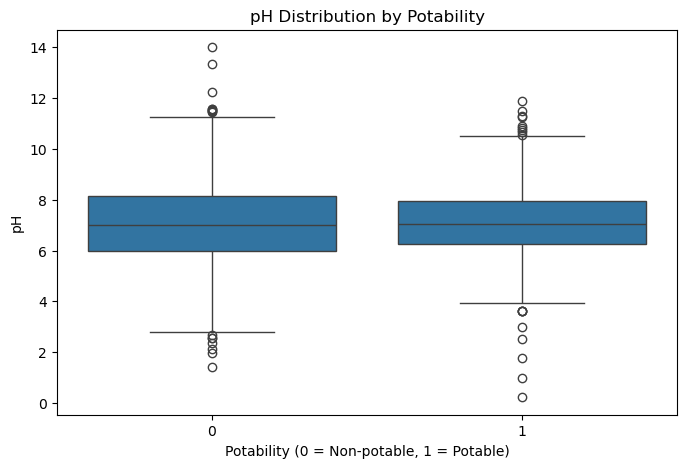

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Potability", y="ph", data=df_cleaned)
plt.title("pH Distribution by Potability")
plt.xlabel("Potability (0 = Non-potable, 1 = Potable)")
plt.ylabel("pH")
plt.show()

#### Sulfate Boxplot

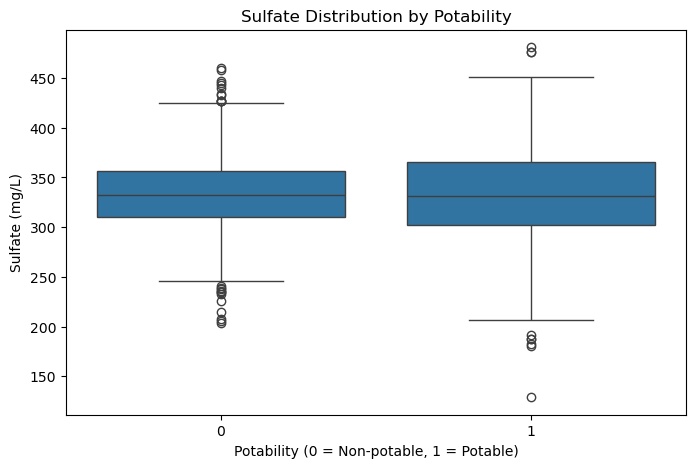

In [36]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Potability", y="Sulfate", data=df_cleaned)
plt.title("Sulfate Distribution by Potability")
plt.xlabel("Potability (0 = Non-potable, 1 = Potable)")
plt.ylabel("Sulfate (mg/L)")
plt.show()

#### Solids Boxplot

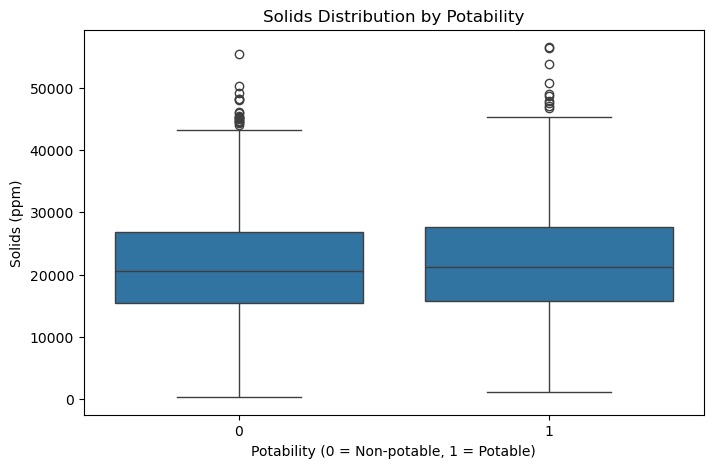

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Potability", y="Solids", data=df_cleaned)
plt.title("Solids Distribution by Potability")
plt.xlabel("Potability (0 = Non-potable, 1 = Potable)")
plt.ylabel("Solids (ppm)")
plt.show()

#### Turbidity Boxplot

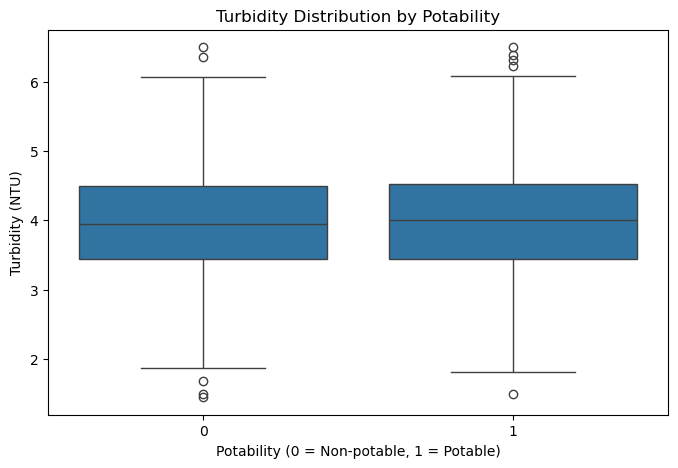

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Potability", y="Turbidity", data=df_cleaned)
plt.title("Turbidity Distribution by Potability")
plt.xlabel("Potability (0 = Non-potable, 1 = Potable)")
plt.ylabel("Turbidity (NTU)")
plt.show()

#### Chloramines Boxplot

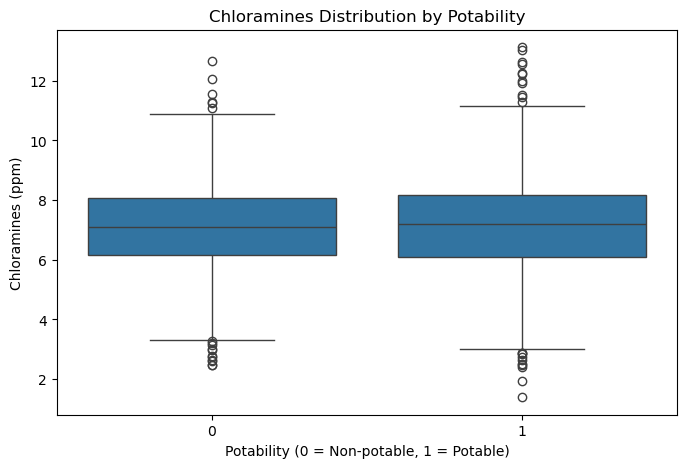

In [42]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Potability", y="Chloramines", data=df_cleaned)
plt.title("Chloramines Distribution by Potability")
plt.xlabel("Potability (0 = Non-potable, 1 = Potable)")
plt.ylabel("Chloramines (ppm)")
plt.show()

### Key Insights

- Non-potable water samples generally show lower pH and higher Sulfate levels.
- Solids, Turbidity, and Chloramines distributions overlap but show slight shifts between groups.
- No single feature perfectly separates potable from non-potable water. The patterns are subtle and multi-factorial, suggesting that potability depends on a combination of indicators rather than any single one.

#### Limitations
*Note: This analysis does not explore derived features (e.g., PCA1, Cluster) in boxplots as they are not original indicators.*

### Final Takeaway

Descriptive analysis shows that potable water tends to have higher pH and lower Sulfate levels compared to non-potable water. Solids, Turbidity, and Chloramines also show differences, though with overlapping distributions. Overall, potability likely depends on a combination of indicators rather than any single one.

---

**Contributors:**  
- Khivanraj – Exploratory Analysis (PCA, Clustering, Correlation)  
- Yubbhashana A/P Danesh – Descriptive Analysis (Statistics, Visual Comparisons)